In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm


# ============================================================================
# Configuration
# ============================================================================

CSV_DIRECTORY = Path("rys_results")
OUTPUT_PATH = CSV_DIRECTORY / "heatmaps" / "six_models_comparison.png"

METRIC = "combined_sentence_acc"
USE_DELTA = True
ANNOTATE = True

METRICS = [
    "blimp_fast",
    "supplement_fast",
    "ewok_fast",
    "entity_tracking_fast",
    "combined_sentence_acc",
    "eye_tracking_score",
    "self_paced_reading_score",
]

In [21]:
# ============================================================================
# Read CSV files
# ============================================================================

def read_csv_files(directory: str | Path) -> dict[str, pd.DataFrame]:
    directory = Path(directory)

    if not directory.exists():
        raise FileNotFoundError(f"Directory not found: {directory}")

    csv_files = sorted(directory.glob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {directory}")

    datasets = {}

    print(f"CSV files found in: {directory.resolve()}\n")

    for csv_path in csv_files:
        size_mb = csv_path.stat().st_size / (1024 ** 2)
        df = pd.read_csv(csv_path)

        datasets[csv_path.stem] = df

        print(f"{csv_path.name}")
        print(f"  File size: {size_mb:.3f} MB")
        print(f"  Rows:      {len(df):,}")
        print(f"  Columns:   {len(df.columns):,}")
        print()

    return datasets


# ============================================================================
# Construct RYS matrix
# ============================================================================

def make_rys_matrix(
    df: pd.DataFrame,
    reference_baseline_value: float,
    metric: str = "combined_sentence_acc",
    use_delta: bool = True,
):
    """
    Construct the RYS matrix for one model.

    When use_delta=True, every RYS result is compared against the same
    original authors' baseline value supplied through
    reference_baseline_value.
    """
    df = df.copy()

    required_columns = {
        "rys_start",
        "rys_end",
        "execution_layers",
        metric,
    }

    missing_columns = required_columns - set(df.columns)

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    # This model's own no-repetition row is used only to determine
    # architecture information and report its own baseline.
    own_baseline_rows = df[
        (df["rys_start"] == 0)
        & (df["rys_end"] == 0)
    ]

    if own_baseline_rows.empty:
        raise ValueError(
            "No no-repetition row found. "
            "Expected rys_start=0 and rys_end=0."
        )

    if len(own_baseline_rows) > 1:
        raise ValueError(
            "Multiple no-repetition rows found. "
            "Expected exactly one row with rys_start=0 and rys_end=0."
        )

    own_baseline_row = own_baseline_rows.iloc[0]
    own_baseline_value = float(own_baseline_row[metric])

    # Keep only actual repetition configurations.
    rys = df[
        ~(
            (df["rys_start"] == 0)
            & (df["rys_end"] == 0)
        )
    ].copy()

    rys = rys.dropna(subset=[metric])

    if rys.empty:
        raise ValueError(
            f"No valid RYS configurations found for metric '{metric}'."
        )

    if use_delta:
        value_col = f"delta_vs_original_baseline_{metric}"

        # Critical change:
        # subtract the fixed authors' baseline, not this model's own baseline.
        rys[value_col] = (
            rys[metric] - float(reference_baseline_value)
        )
    else:
        value_col = metric

    original_n_layers = int(
        own_baseline_row["execution_layers"]
    )

    matrix = np.full(
        (original_n_layers, original_n_layers + 1),
        np.nan,
    )

    for _, row in rys.iterrows():
        i = int(row["rys_start"])
        j = int(row["rys_end"])

        if 0 <= i < original_n_layers and 0 <= j <= original_n_layers:
            matrix[i, j] = float(row[value_col])

    if np.all(np.isnan(matrix)):
        raise ValueError(
            f"The RYS matrix contains no valid values for '{metric}'."
        )

    return (
        matrix,
        float(reference_baseline_value),
        own_baseline_value,
        value_col,
    )


# ============================================================================
# Plot one model on an existing subplot
# ============================================================================

def plot_rys_on_axis(
    ax,
    df: pd.DataFrame,
    model_name: str,
    reference_baseline_value: float,
    metric: str = "combined_sentence_acc",
    use_delta: bool = True,
    annotate: bool = True,
    norm=None,
):
    (
        matrix,
        original_baseline_value,
        own_baseline_value,
        value_col,
    ) = make_rys_matrix(
        df=df,
        reference_baseline_value=reference_baseline_value,
        metric=metric,
        use_delta=use_delta,
    )

    best_flat_index = np.nanargmax(matrix)
    best_i, best_j = np.unravel_index(
        best_flat_index,
        matrix.shape,
    )

    best_plotted_value = float(matrix[best_i, best_j])

    # Recover the absolute score represented by the best cell.
    if use_delta:
        best_score = (
            original_baseline_value + best_plotted_value
        )
    else:
        best_score = best_plotted_value

    delta_vs_original_baseline = (
        best_score - original_baseline_value
    )

    delta_vs_own_baseline = (
        best_score - own_baseline_value
    )

    cmap = "RdBu_r" if use_delta else "viridis"

    image = ax.imshow(
        matrix,
        origin="upper",
        aspect="auto",
        cmap=cmap,
        norm=norm,
    )

    n_layers = matrix.shape[0]

    ax.set_title(
        f"{model_name}\n"
        f"Best [{best_i}, {best_j}) | "
        f"score={best_score:.4f} | "
        f"Δ original={delta_vs_original_baseline:+.4f}",
        fontsize=10,
    )

    ax.set_xlabel("j (end)")
    ax.set_ylabel("i (start)")

    ax.set_xticks(range(n_layers + 1))
    ax.set_yticks(range(n_layers))

    # Highlight the configuration with the highest absolute score.
    ax.scatter(
        best_j,
        best_i,
        s=220,
        facecolors="none",
        edgecolors="lime",
        linewidths=3,
    )

    if annotate:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                value = matrix[i, j]

                if np.isnan(value):
                    continue

                # Improve readability on dark cells.
                if norm is not None:
                    normalized_value = norm(value)
                    text_color = (
                        "white"
                        if normalized_value < 0.22
                        or normalized_value > 0.78
                        else "black"
                    )
                else:
                    text_color = "black"

                ax.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color=text_color,
                )

    result = {
        "model": model_name,
        "metric": metric,
        "best_start": best_i,
        "best_end": best_j,
        "best_rys_block": f"[{best_i}, {best_j})",

        # Fixed reference for every model.
        "original_baseline": original_baseline_value,

        # This model without RYS, included for interpretation.
        "own_baseline": own_baseline_value,

        # Best absolute result from this model's RYS sweep.
        "best_rys_score": best_score,

        # Main quantity represented by the heatmap.
        "delta_vs_original_baseline": (
            delta_vs_original_baseline
        ),

        # Additional diagnostic: isolated effect of RYS.
        "delta_vs_own_baseline": delta_vs_own_baseline,
    }

    return image, result


# ============================================================================
# Plot all models
# ============================================================================

def plot_model_comparison(
    datasets: dict[str, pd.DataFrame],
    metric: str = "combined_sentence_acc",
    reference_model: str = "rys_baseline_summary",
    use_delta: bool = True,
    annotate: bool = True,
    output_path: str | Path | None = None,
):
    if len(datasets) != 6:
        raise ValueError(
            f"Expected exactly 5 CSV files, but found {len(datasets)}."
        )

    if reference_model not in datasets:
        raise KeyError(
            f"Reference file '{reference_model}' was not found.\n"
            f"Available datasets: {list(datasets.keys())}"
        )

    # ------------------------------------------------------------------------
    # Read the fixed original authors' baseline
    # ------------------------------------------------------------------------

    reference_df = datasets[reference_model]

    if metric not in reference_df.columns:
        raise ValueError(
            f"Metric '{metric}' is missing from the reference file "
            f"'{reference_model}'."
        )

    reference_rows = reference_df[
        (reference_df["rys_start"] == 0)
        & (reference_df["rys_end"] == 0)
    ]

    if reference_rows.empty:
        raise ValueError(
            f"No original no-repetition baseline was found in "
            f"'{reference_model}'. Expected rys_start=0 and rys_end=0."
        )

    if len(reference_rows) > 1:
        raise ValueError(
            f"Multiple no-repetition rows were found in "
            f"'{reference_model}'."
        )

    reference_baseline_value = float(
        reference_rows.iloc[0][metric]
    )

    print(
        f"\nMetric: {metric}\n"
        f"Reference model: {reference_model}\n"
        f"Original authors' baseline: "
        f"{reference_baseline_value:.6f}"
    )

    # ------------------------------------------------------------------------
    # Build all matrices using the same fixed reference
    # ------------------------------------------------------------------------

    matrices = []

    for model_name, df in datasets.items():
        matrix, _, _, _ = make_rys_matrix(
            df=df,
            reference_baseline_value=reference_baseline_value,
            metric=metric,
            use_delta=use_delta,
        )

        matrices.append(matrix)

    # Every model uses the same color scale.
    if use_delta:
        global_limit = max(
            np.nanmax(np.abs(matrix))
            for matrix in matrices
        )

        if global_limit == 0:
            global_limit = 1e-8

        shared_norm = TwoSlopeNorm(
            vmin=-global_limit,
            vcenter=0.0,
            vmax=global_limit,
        )
    else:
        global_min = min(
            np.nanmin(matrix)
            for matrix in matrices
        )
        global_max = max(
            np.nanmax(matrix)
            for matrix in matrices
        )

        shared_norm = plt.Normalize(
            vmin=global_min,
            vmax=global_max,
        )

    # ------------------------------------------------------------------------
    # Three model columns + dedicated color-bar column
    # ------------------------------------------------------------------------

    fig = plt.figure(
        figsize=(25, 14),
        constrained_layout=True,
    )

    grid = fig.add_gridspec(
        nrows=2,
        ncols=4,
        width_ratios=[1, 1, 1, 0.045],
        height_ratios=[1, 1],
        wspace=0.08,
        hspace=0.15,
    )

    axes = np.array(
        [
            [
                fig.add_subplot(grid[0, 0]),
                fig.add_subplot(grid[0, 1]),
                fig.add_subplot(grid[0, 2]),
            ],
            [
                fig.add_subplot(grid[1, 0]),
                fig.add_subplot(grid[1, 1]),
                fig.add_subplot(grid[1, 2]),
            ],
        ]
    )

    colorbar_ax = fig.add_subplot(grid[:, 3])

    results = []
    last_image = None

    for ax, (model_name, df) in zip(
        axes.flat,
        datasets.items(),
    ):
        last_image, result = plot_rys_on_axis(
            ax=ax,
            df=df,
            model_name=model_name,
            reference_baseline_value=reference_baseline_value,
            metric=metric,
            use_delta=use_delta,
            annotate=annotate,
            norm=shared_norm,
        )

        results.append(result)

    # Hide the sixth position.
    for ax in axes.flat[len(datasets):]:
        ax.axis("off")

    if use_delta:
        figure_title = (
            f"RYS Model Comparison — {metric}\n"
            f"Delta vs Original Authors' Baseline "
            f"({reference_model}: {reference_baseline_value:.4f})"
        )
    else:
        figure_title = (
            f"RYS Model Comparison — {metric} Absolute Scores"
        )

    fig.suptitle(
        figure_title,
        fontsize=18,
    )

    colorbar = fig.colorbar(
        last_image,
        cax=colorbar_ax,
    )

    colorbar.set_label(
        (
            f"{metric} delta vs original authors' baseline"
            if use_delta
            else metric
        ),
        fontsize=11,
        labelpad=12,
    )

    colorbar.ax.tick_params(labelsize=9)

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            output_path,
            dpi=250,
            facecolor="white",
        )

        print(f"\nFigure saved to: {output_path.resolve()}")

    results_df = pd.DataFrame(results).sort_values(
        "best_rys_score",
        ascending=False,
    )

    print("\nBest RYS result for each model:")
    print(
        results_df.to_string(
            index=False,
            formatters={
                "original_baseline": "{:.4f}".format,
                "own_baseline": "{:.4f}".format,
                "best_rys_score": "{:.4f}".format,
                "delta_vs_original_baseline": "{:+.4f}".format,
                "delta_vs_own_baseline": "{:+.4f}".format,
            },
        )
    )

    return results_df, fig, axes



def plot_all_metrics_comparison(
    datasets: dict[str, pd.DataFrame],
    metrics: list[str],
    reference_model: str = "rys_baseline_summary",
    use_delta: bool = True,
    annotate: bool = True,
):
    all_results = {}

    for metric in metrics:
        print("\n" + "=" * 80)
        print(f"Processing metric: {metric}")
        print("=" * 80)

        missing_models = [
            model_name
            for model_name, df in datasets.items()
            if metric not in df.columns
        ]

        if missing_models:
            print(
                f"Skipping '{metric}' because it is missing from: "
                f"{', '.join(missing_models)}"
            )
            continue

        results_df, fig, axes = plot_model_comparison(
            datasets=datasets,
            metric=metric,
            reference_model=reference_model,
            use_delta=use_delta,
            annotate=annotate,
            output_path=None,
        )

        all_results[metric] = results_df

        plt.show()

    return all_results

CSV files found in: /Users/elizabethgranda/Documents/BabyLM2026/babylm_cl_rys/rys_results

rys_baseline_summary.csv
  File size: 0.006 MB
  Rows:      79
  Columns:   12

rys_cl2_dale_chall.csv
  File size: 0.006 MB
  Rows:      79
  Columns:   12

rys_cl2_gunning_fog.csv
  File size: 0.006 MB
  Rows:      79
  Columns:   12

rys_cl3_summary.csv
  File size: 0.006 MB
  Rows:      79
  Columns:   12

rys_cl4_descending.csv
  File size: 0.006 MB
  Rows:      79
  Columns:   12

rys_cl4_surrogate.csv
  File size: 0.006 MB
  Rows:      79
  Columns:   12


Processing metric: blimp_fast

Metric: blimp_fast
Reference model: rys_baseline_summary
Original authors' baseline: 65.360000

Best RYS result for each model:
               model     metric  best_start  best_end best_rys_block original_baseline own_baseline best_rys_score delta_vs_original_baseline delta_vs_own_baseline
  rys_cl4_descending blimp_fast          10        11       [10, 11)           65.3600      67.5900        67.8000    

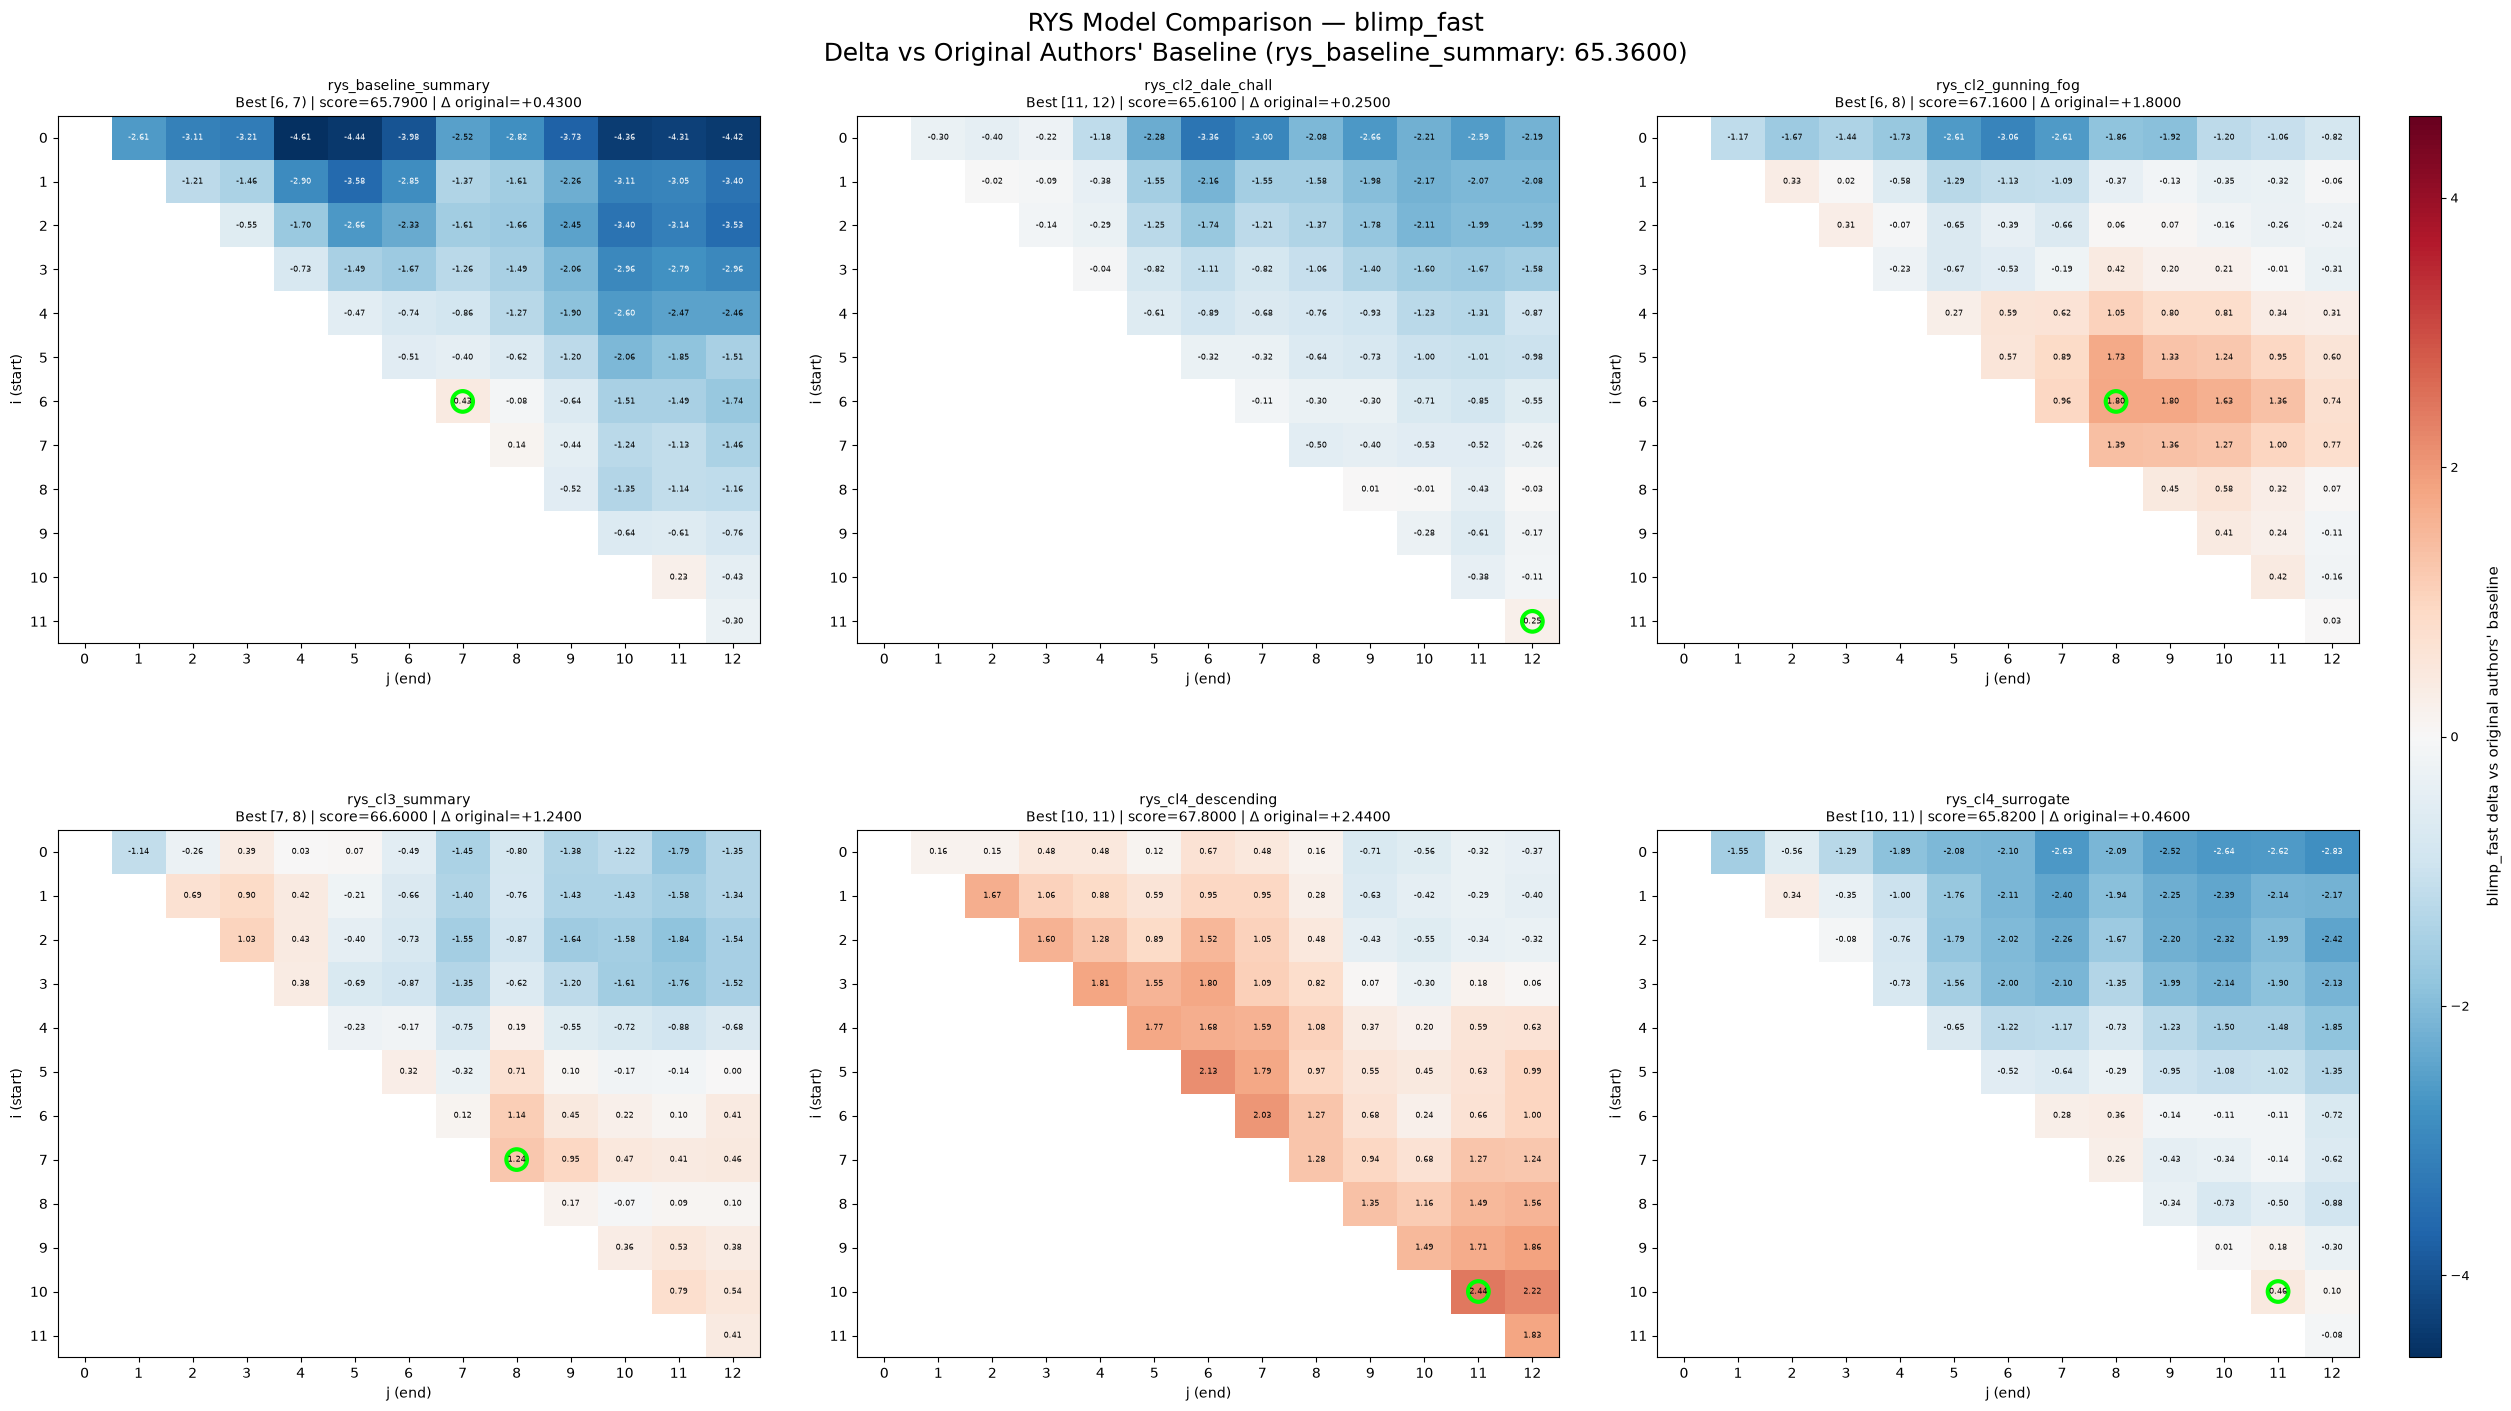


Processing metric: supplement_fast

Metric: supplement_fast
Reference model: rys_baseline_summary
Original authors' baseline: 59.600000

Best RYS result for each model:
               model          metric  best_start  best_end best_rys_block original_baseline own_baseline best_rys_score delta_vs_original_baseline delta_vs_own_baseline
  rys_cl2_dale_chall supplement_fast           4         7         [4, 7)           59.6000      60.8000        63.2000                    +3.6000               +2.4000
 rys_cl2_gunning_fog supplement_fast           0         3         [0, 3)           59.6000      58.4000        62.4000                    +2.8000               +4.0000
   rys_cl4_surrogate supplement_fast           0         5         [0, 5)           59.6000      60.0000        62.0000                    +2.4000               +2.0000
rys_baseline_summary supplement_fast           4         7         [4, 7)           59.6000      59.6000        61.2000                    +1.6000        

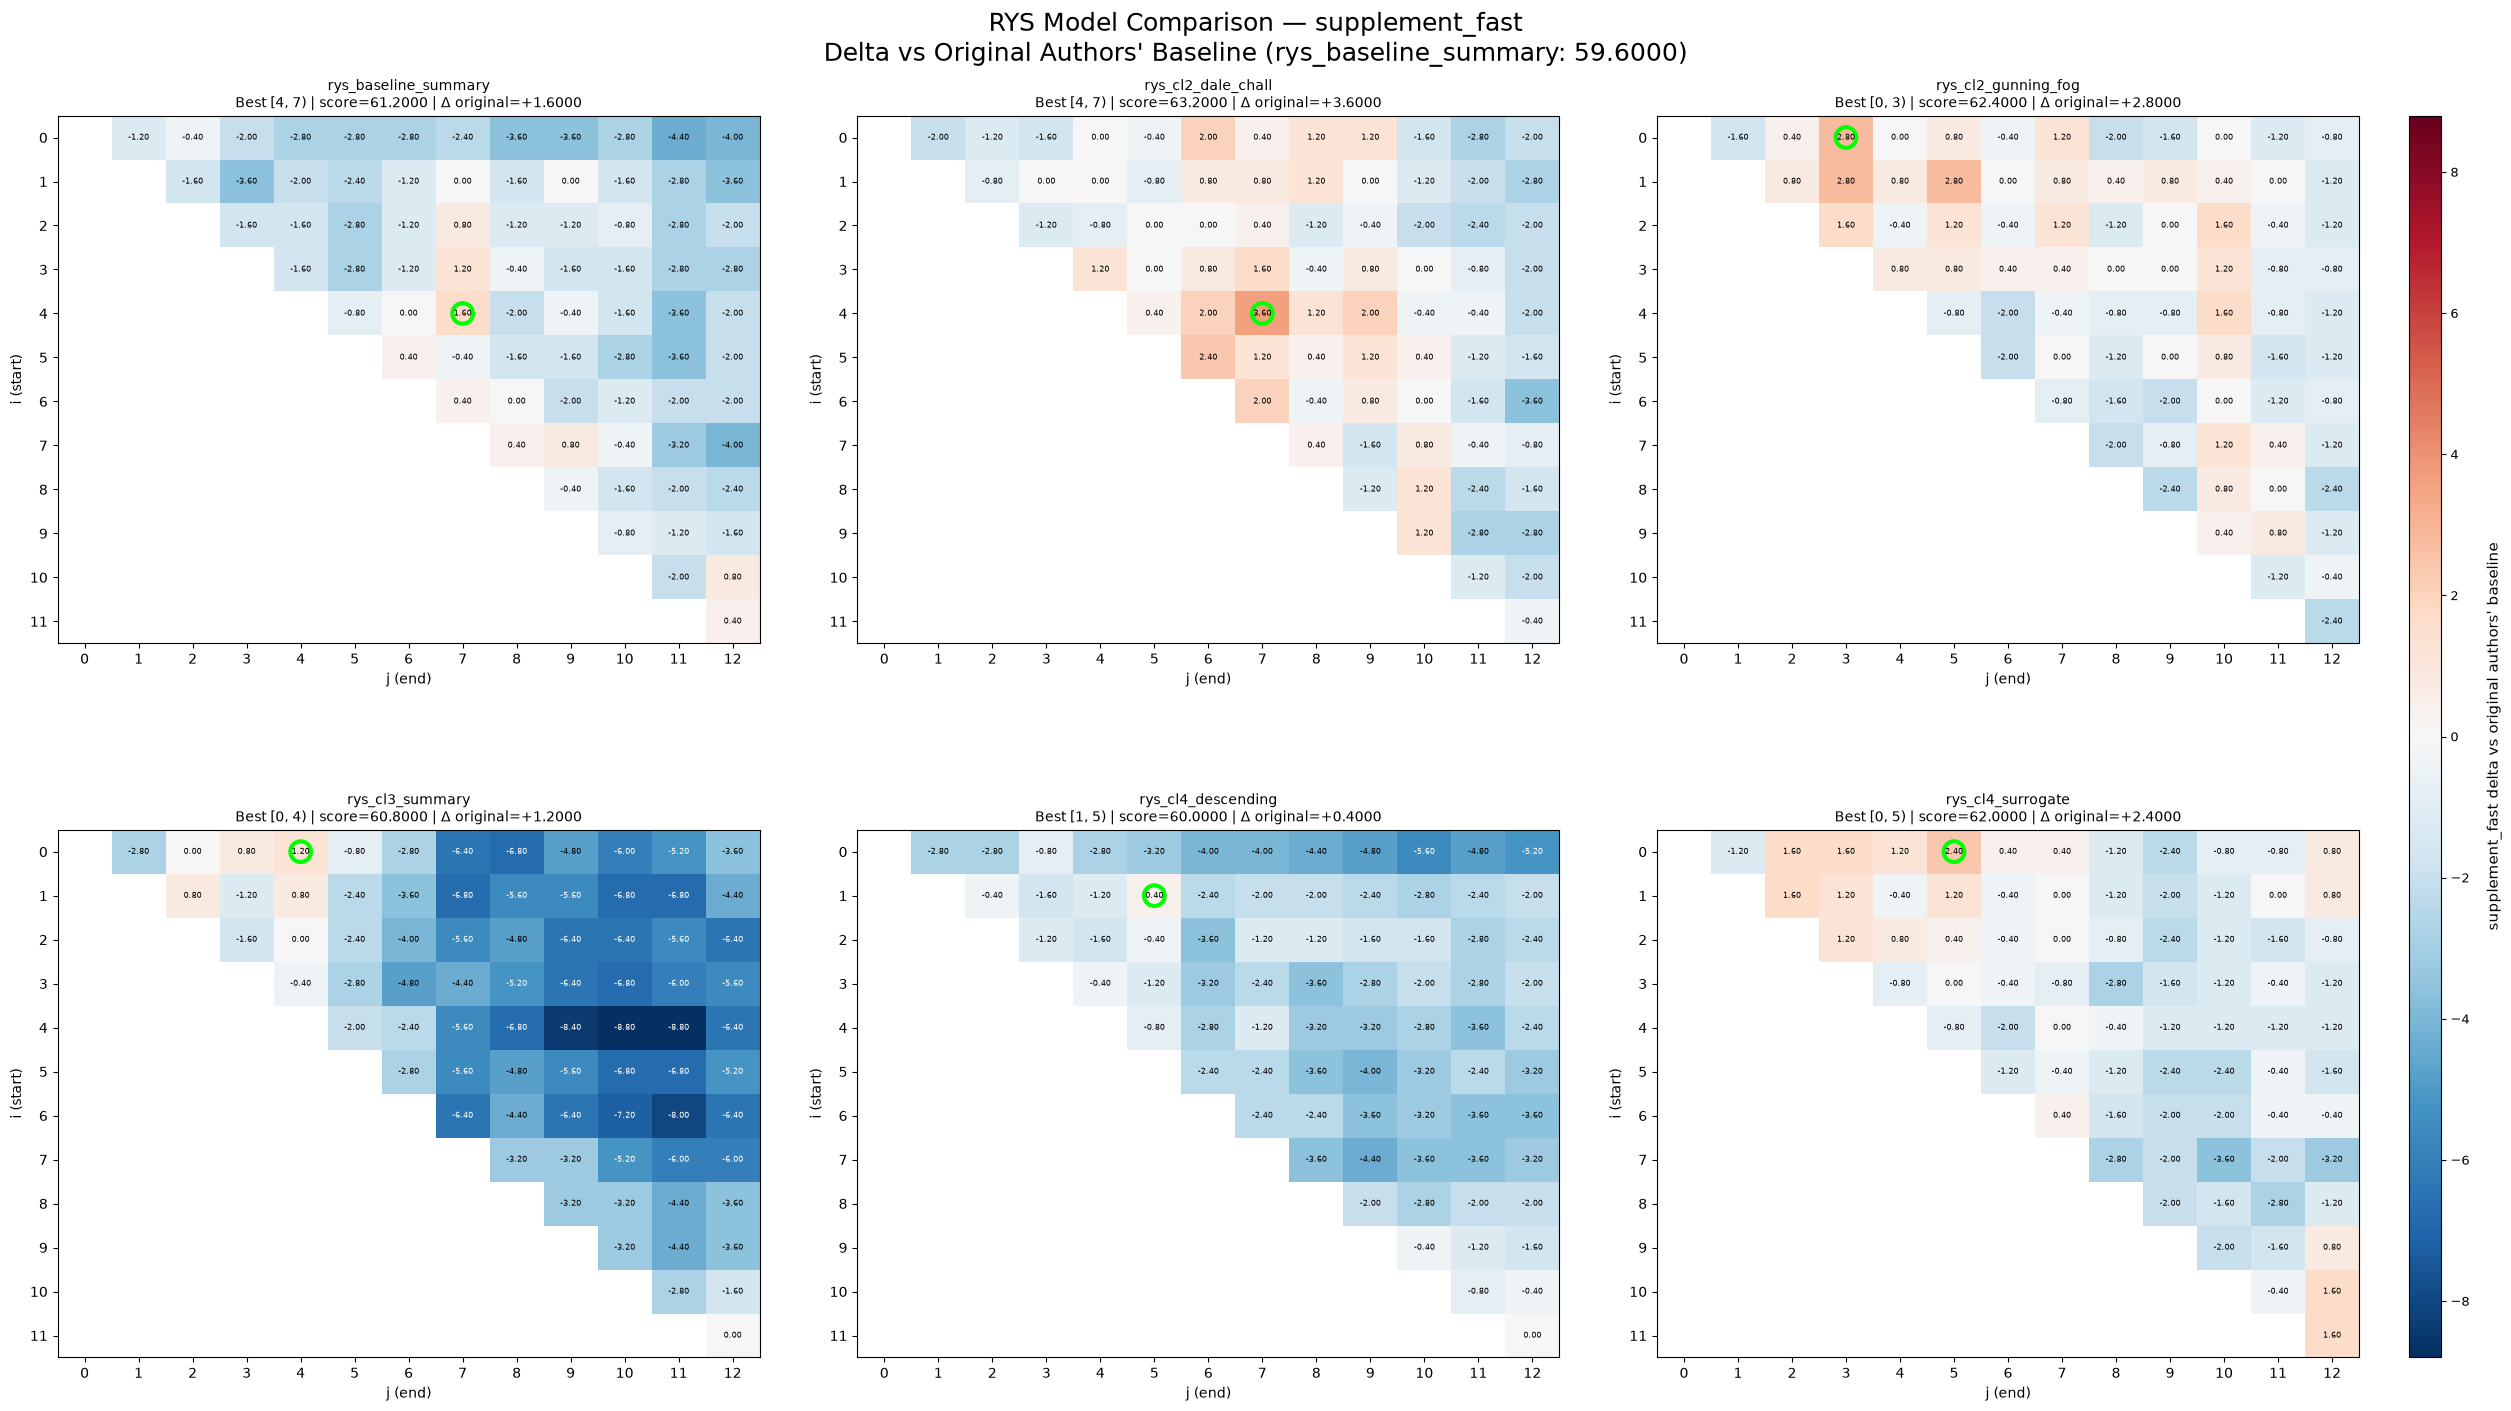


Processing metric: ewok_fast

Metric: ewok_fast
Reference model: rys_baseline_summary
Original authors' baseline: 49.090000

Best RYS result for each model:
               model    metric  best_start  best_end best_rys_block original_baseline own_baseline best_rys_score delta_vs_original_baseline delta_vs_own_baseline
   rys_cl4_surrogate ewok_fast           5         6         [5, 6)           49.0900      50.3600        53.2700                    +4.1800               +2.9100
  rys_cl4_descending ewok_fast           4        12        [4, 12)           49.0900      51.0900        52.9100                    +3.8200               +1.8200
     rys_cl3_summary ewok_fast           7        12        [7, 12)           49.0900      51.0900        52.5500                    +3.4600               +1.4600
  rys_cl2_dale_chall ewok_fast           4         5         [4, 5)           49.0900      50.6400        51.9100                    +2.8200               +1.2700
rys_baseline_summary ewok_f

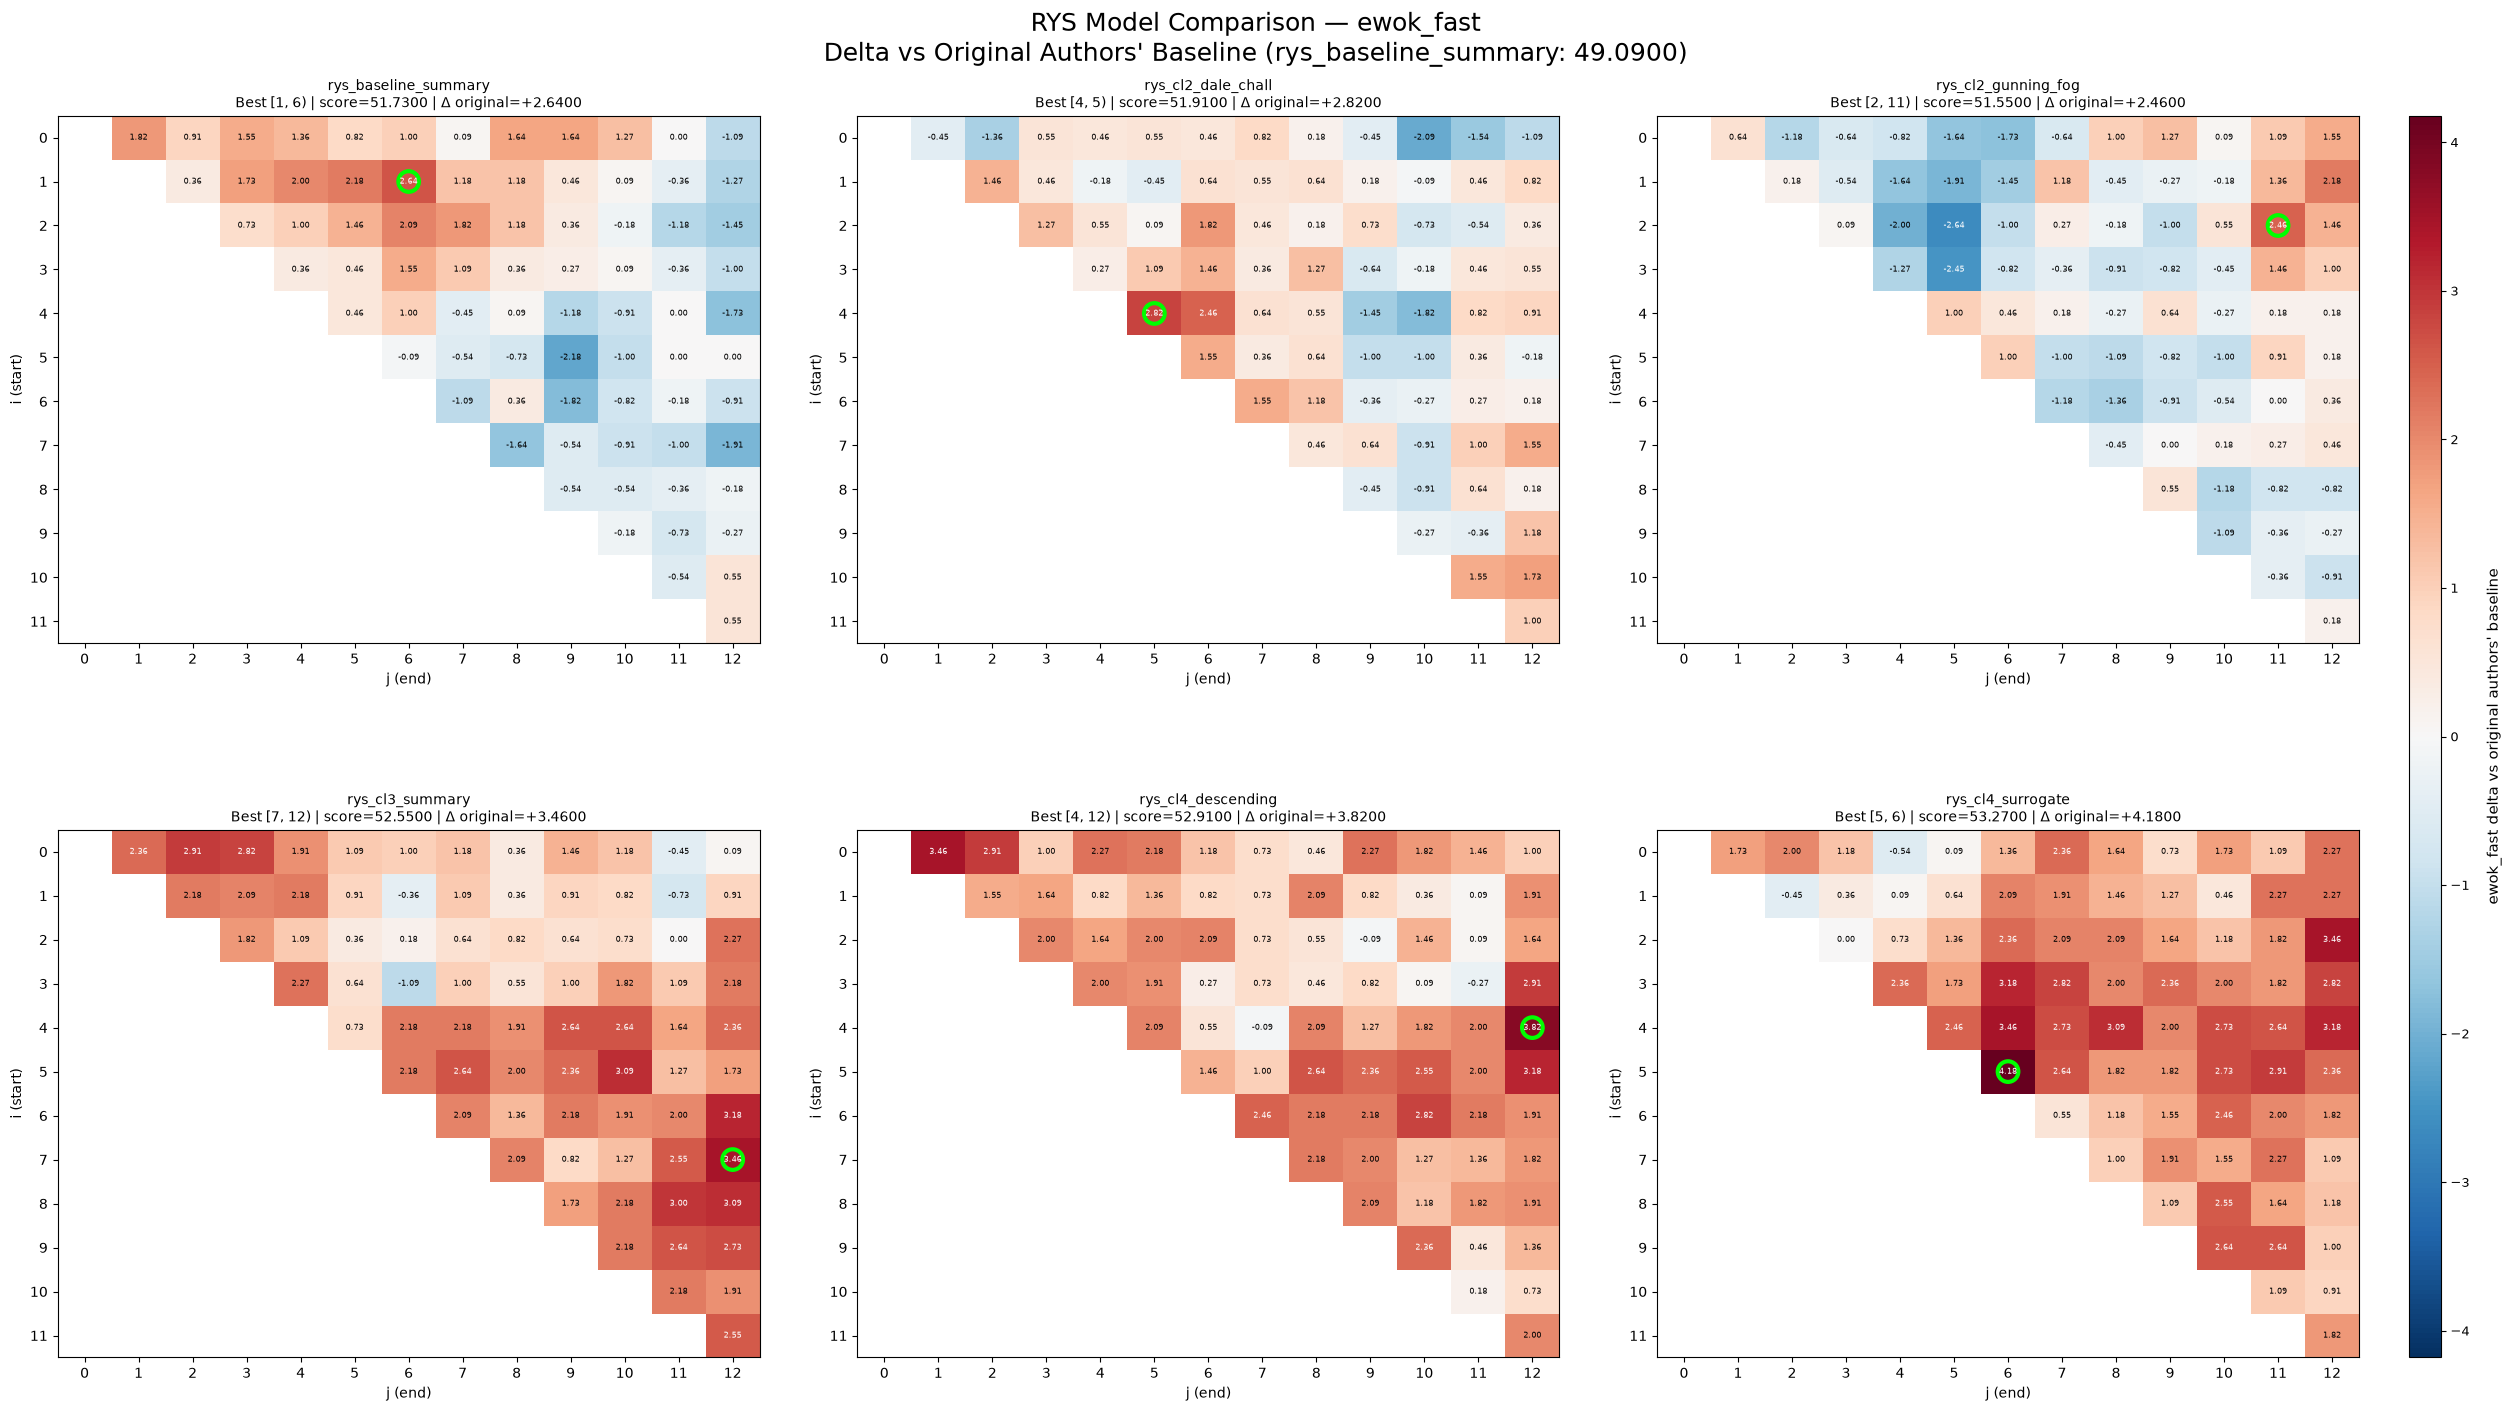


Processing metric: entity_tracking_fast

Metric: entity_tracking_fast
Reference model: rys_baseline_summary
Original authors' baseline: 19.100000

Best RYS result for each model:
               model               metric  best_start  best_end best_rys_block original_baseline own_baseline best_rys_score delta_vs_original_baseline delta_vs_own_baseline
rys_baseline_summary entity_tracking_fast           2         5         [2, 5)           19.1000      19.1000        21.4900                    +2.3900               +2.3900
 rys_cl2_gunning_fog entity_tracking_fast           2        12        [2, 12)           19.1000      19.4700        20.3900                    +1.2900               +0.9200
     rys_cl3_summary entity_tracking_fast           0         4         [0, 4)           19.1000      17.4400        19.3500                    +0.2500               +1.9100
  rys_cl2_dale_chall entity_tracking_fast          10        12       [10, 12)           19.1000      18.2500        18.7700

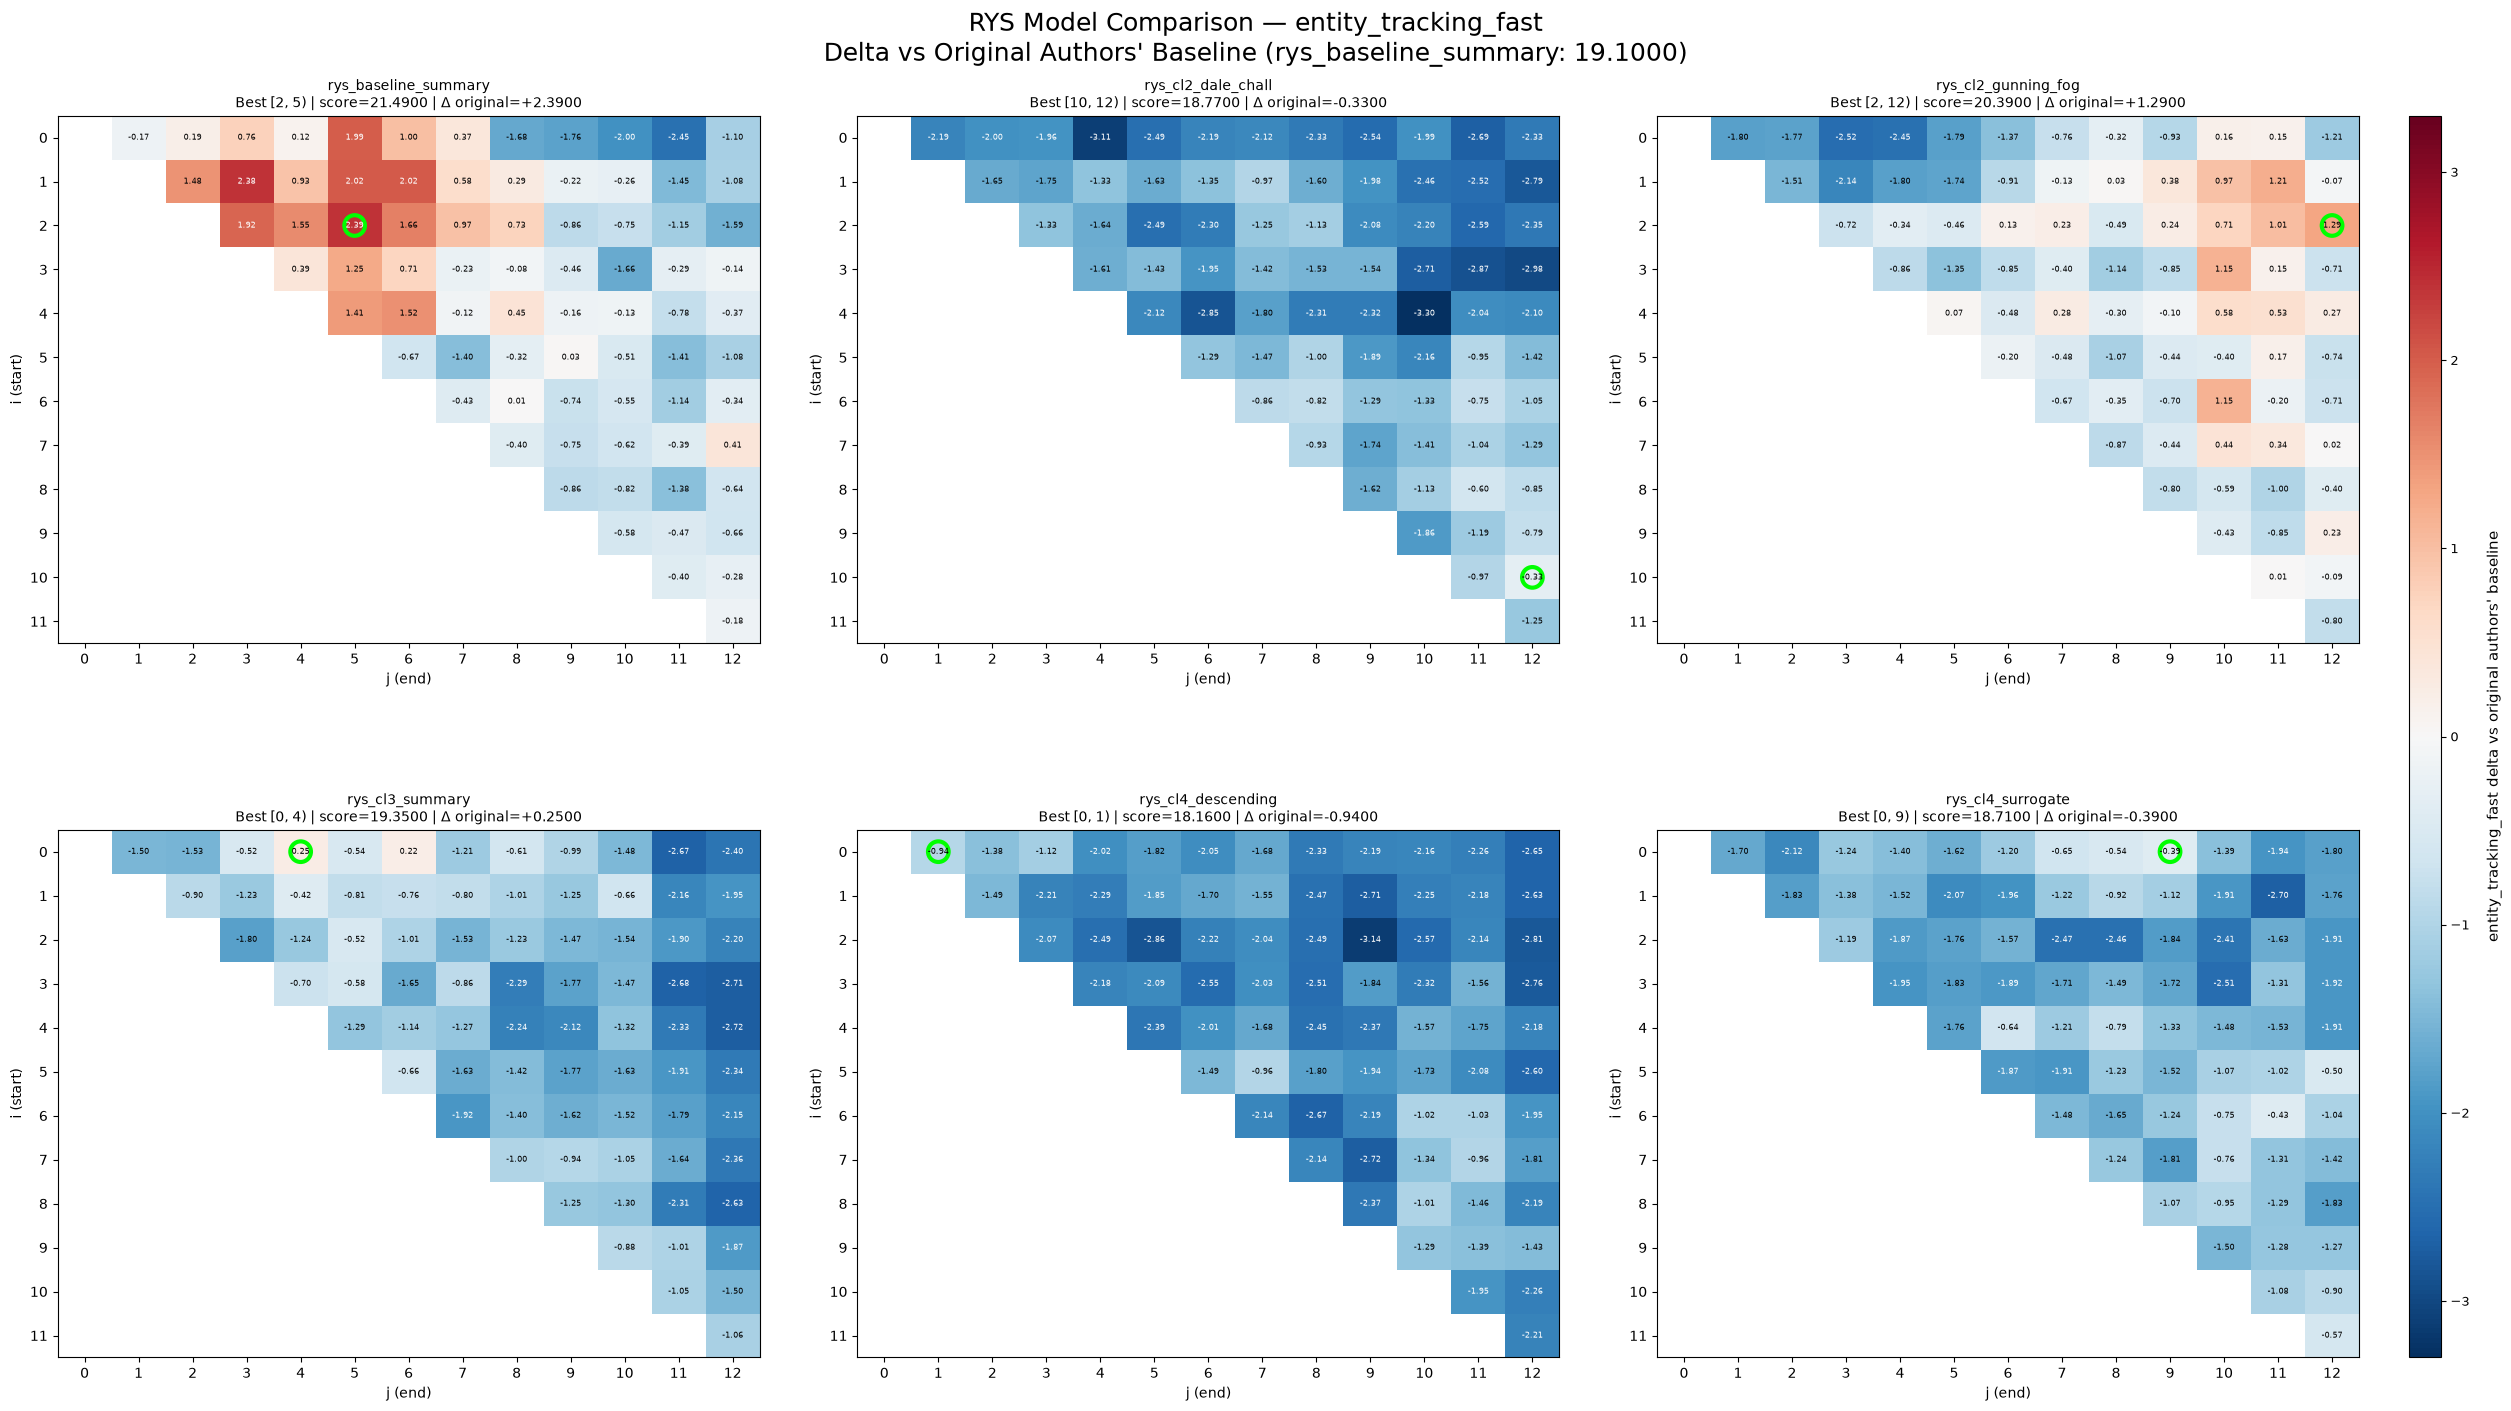


Processing metric: combined_sentence_acc

Metric: combined_sentence_acc
Reference model: rys_baseline_summary
Original authors' baseline: 48.287500

Best RYS result for each model:
               model                metric  best_start  best_end best_rys_block original_baseline own_baseline best_rys_score delta_vs_original_baseline delta_vs_own_baseline
     rys_cl3_summary combined_sentence_acc           0         3         [0, 3)           48.2875      48.3500        49.1600                    +0.8725               +0.8100
 rys_cl2_gunning_fog combined_sentence_acc           7        10        [7, 10)           48.2875      48.3525        49.0600                    +0.7725               +0.7075
   rys_cl4_surrogate combined_sentence_acc          11        12       [11, 12)           48.2875      48.4400        48.9800                    +0.6925               +0.5400
  rys_cl2_dale_chall combined_sentence_acc           6         7         [6, 7)           48.2875      48.7725        

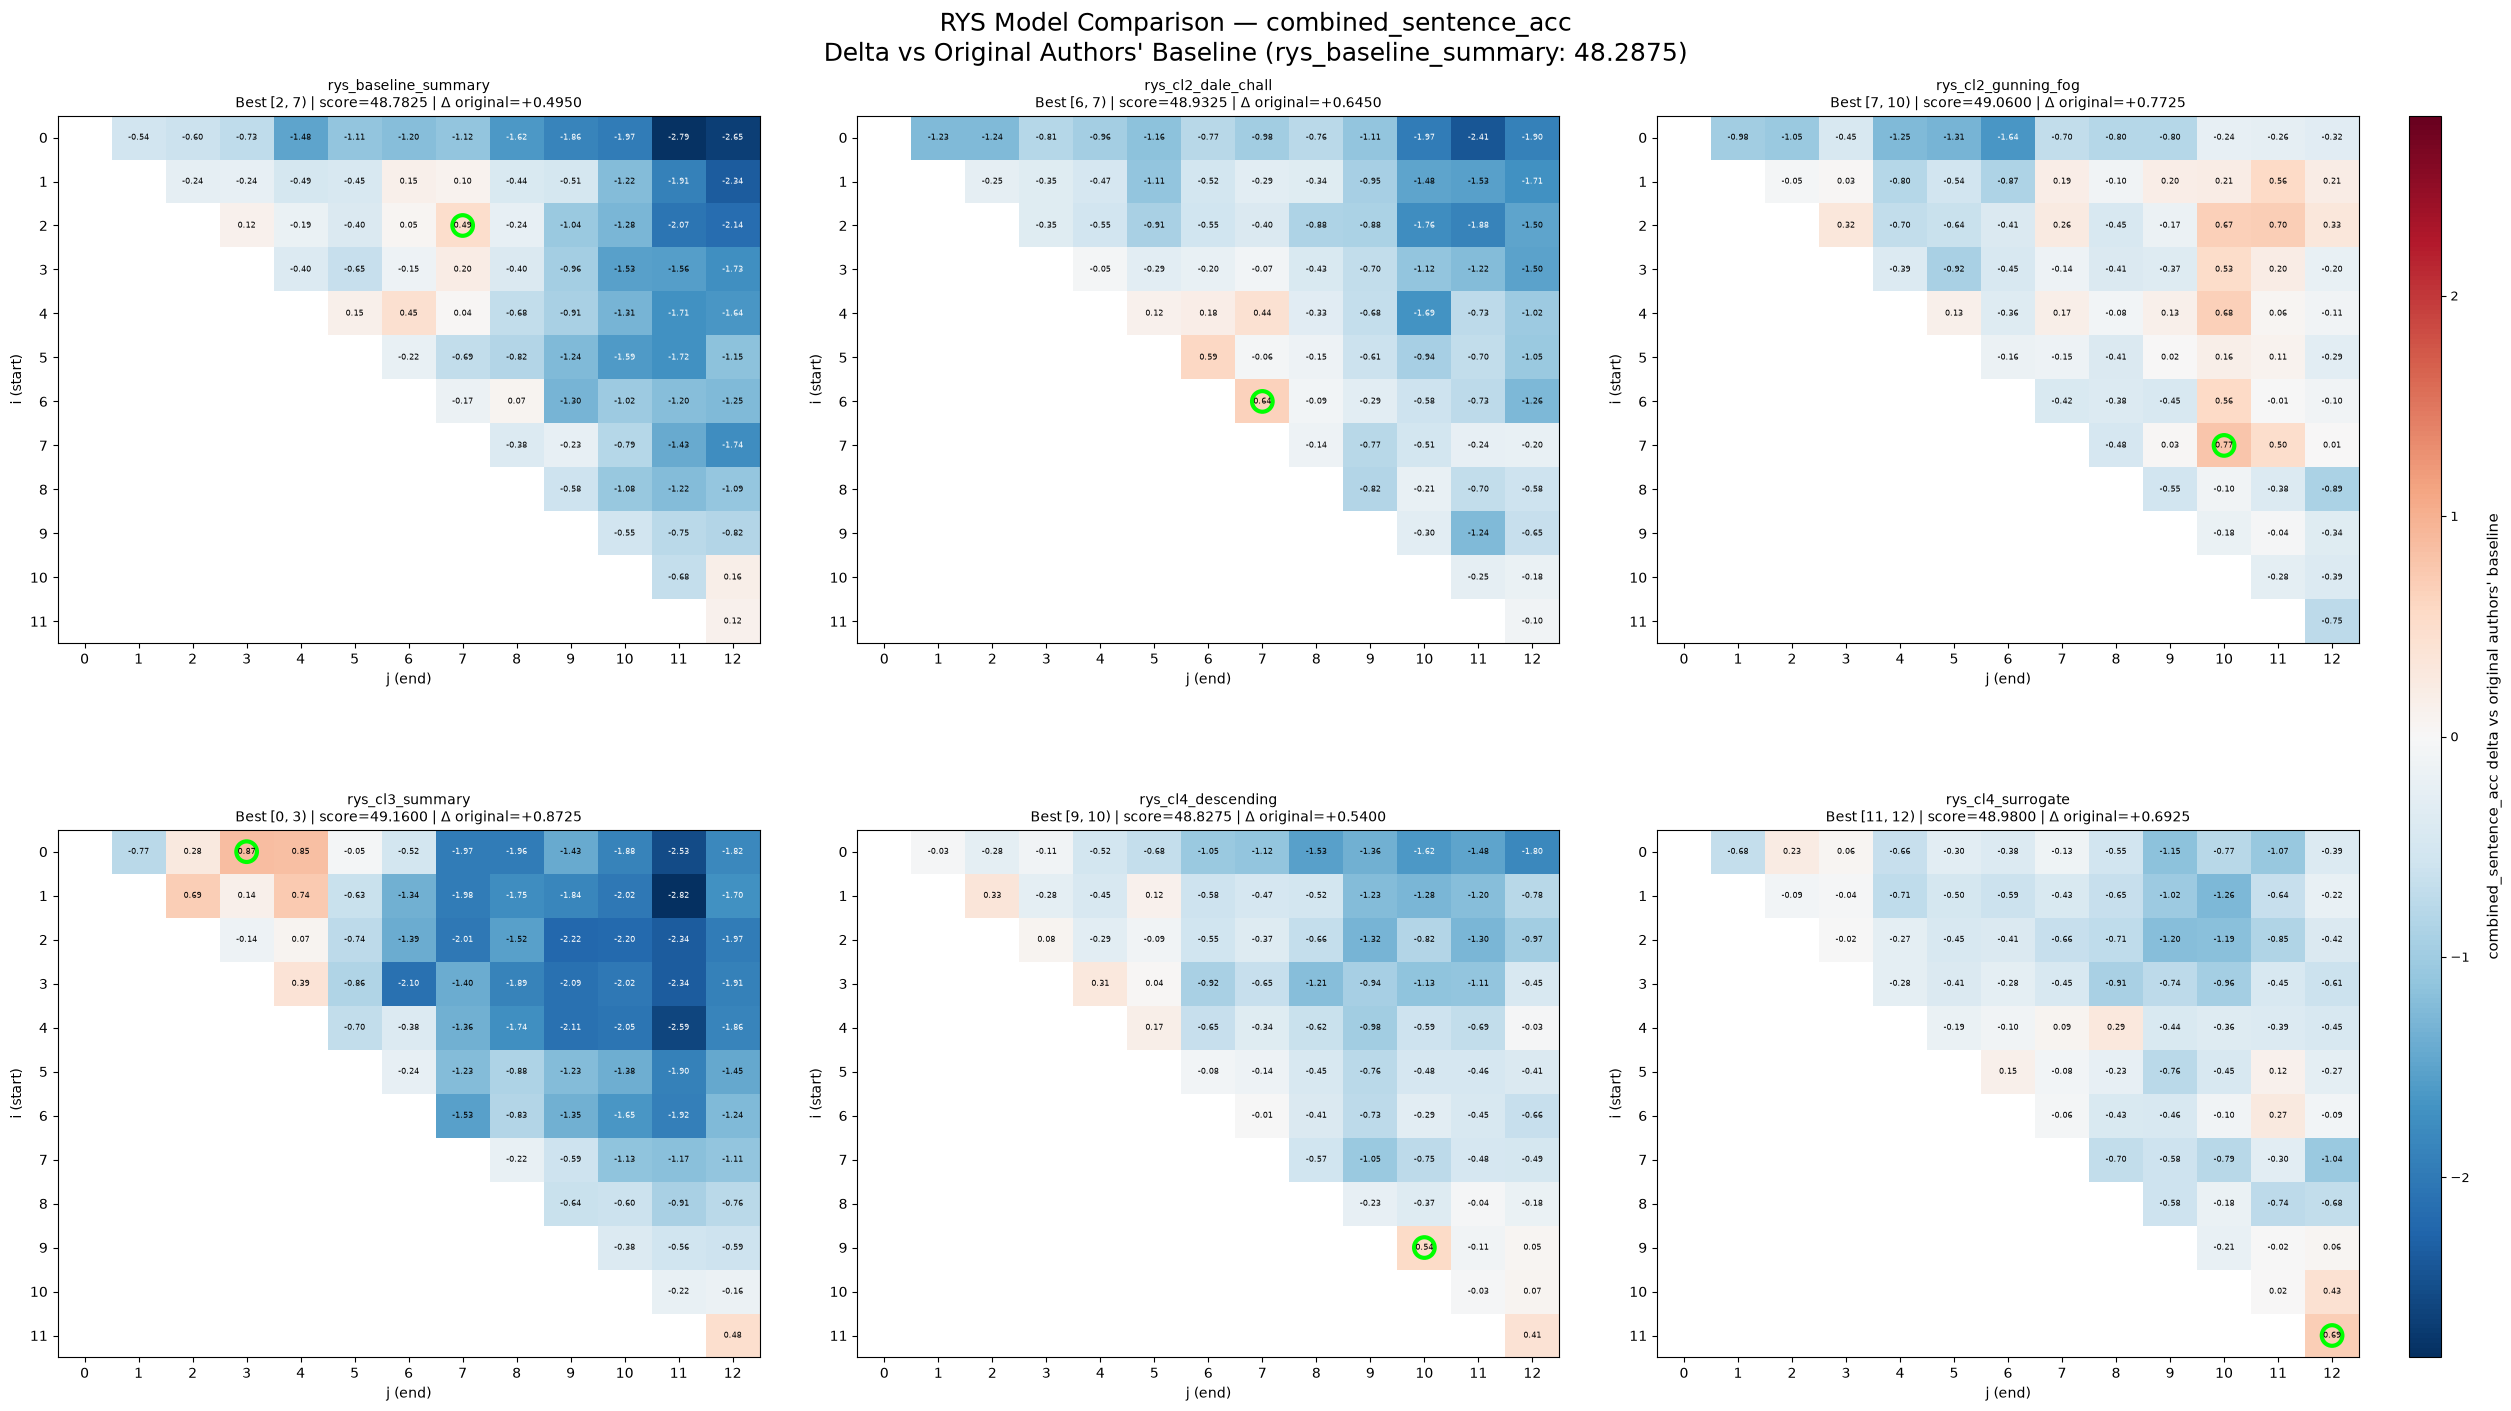


Processing metric: eye_tracking_score

Metric: eye_tracking_score
Reference model: rys_baseline_summary
Original authors' baseline: 9.630000

Best RYS result for each model:
               model             metric  best_start  best_end best_rys_block original_baseline own_baseline best_rys_score delta_vs_original_baseline delta_vs_own_baseline
rys_baseline_summary eye_tracking_score           0         5         [0, 5)            9.6300       9.6300        11.6000                    +1.9700               +1.9700
  rys_cl2_dale_chall eye_tracking_score           1        10        [1, 10)            9.6300       7.3900         9.2600                    -0.3700               +1.8700
   rys_cl4_surrogate eye_tracking_score           0         1         [0, 1)            9.6300       8.5500         9.2200                    -0.4100               +0.6700
 rys_cl2_gunning_fog eye_tracking_score           2        11        [2, 11)            9.6300       6.2500         9.1700               

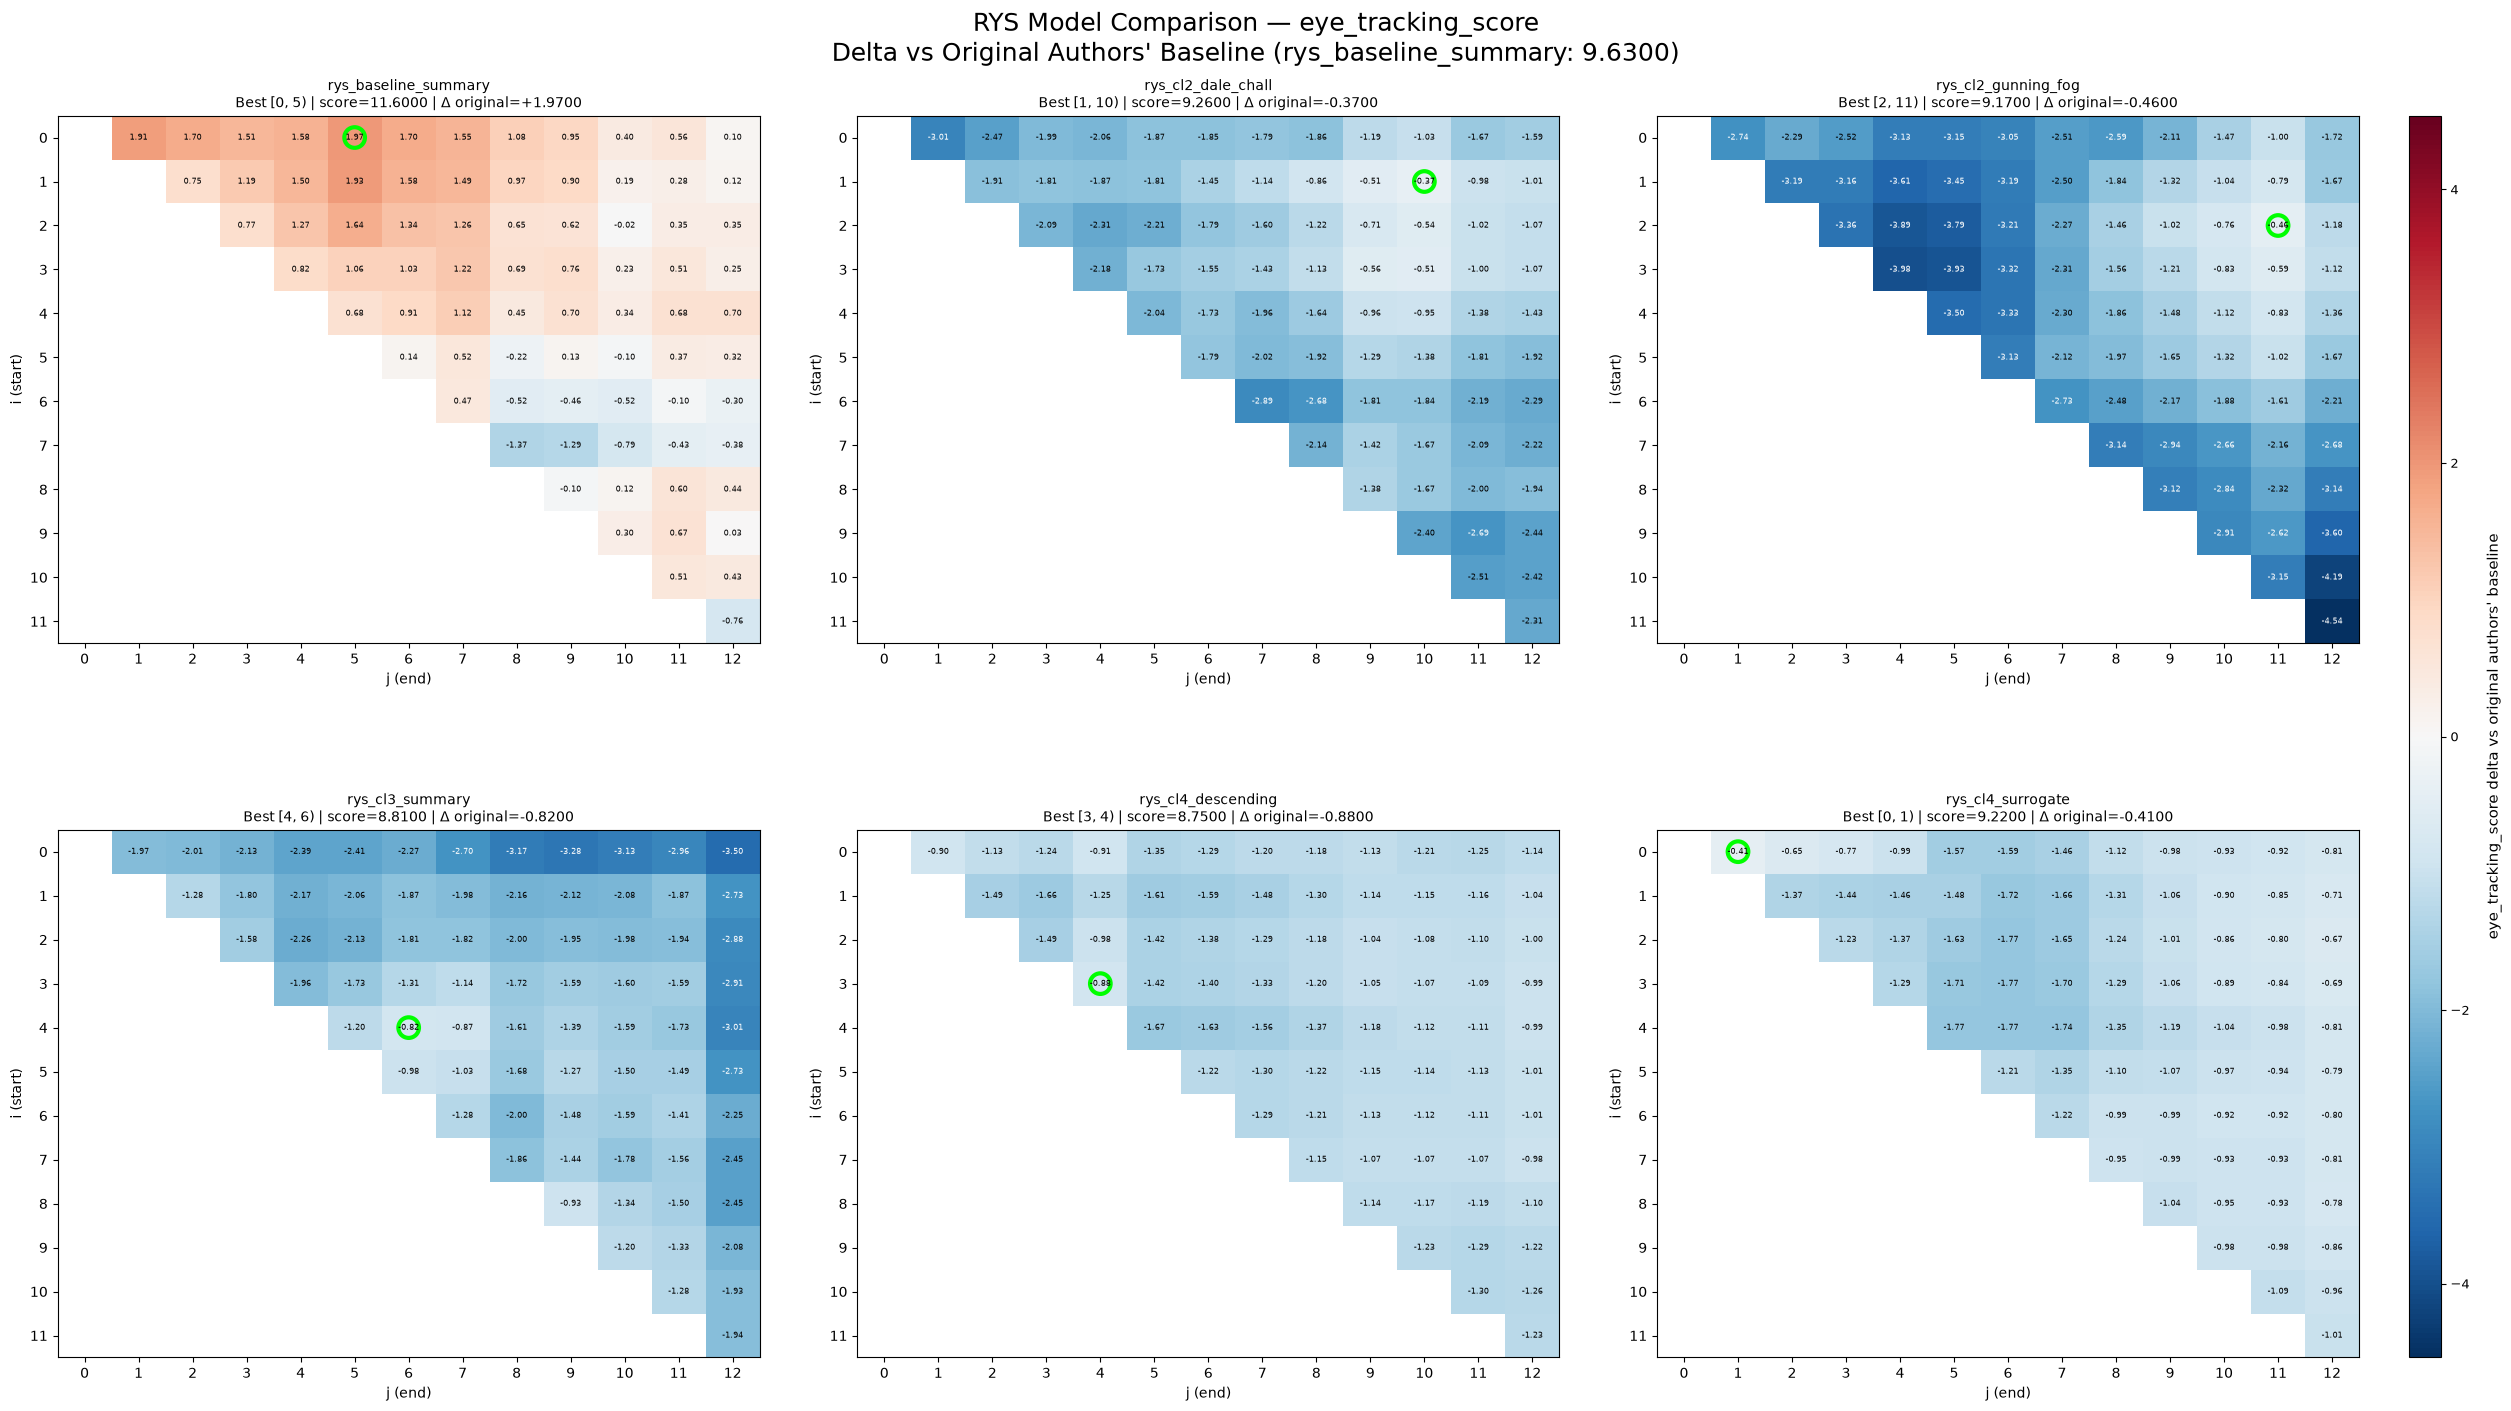


Processing metric: self_paced_reading_score

Metric: self_paced_reading_score
Reference model: rys_baseline_summary
Original authors' baseline: 1.640000

Best RYS result for each model:
               model                   metric  best_start  best_end best_rys_block original_baseline own_baseline best_rys_score delta_vs_original_baseline delta_vs_own_baseline
  rys_cl2_dale_chall self_paced_reading_score           6        10        [6, 10)            1.6400       3.0700         3.6300                    +1.9900               +0.5600
  rys_cl4_descending self_paced_reading_score           1        12        [1, 12)            1.6400       2.8900         3.0600                    +1.4200               +0.1700
   rys_cl4_surrogate self_paced_reading_score           0         1         [0, 1)            1.6400       2.7500         2.9900                    +1.3500               +0.2400
 rys_cl2_gunning_fog self_paced_reading_score           6         9         [6, 9)            1.6400 

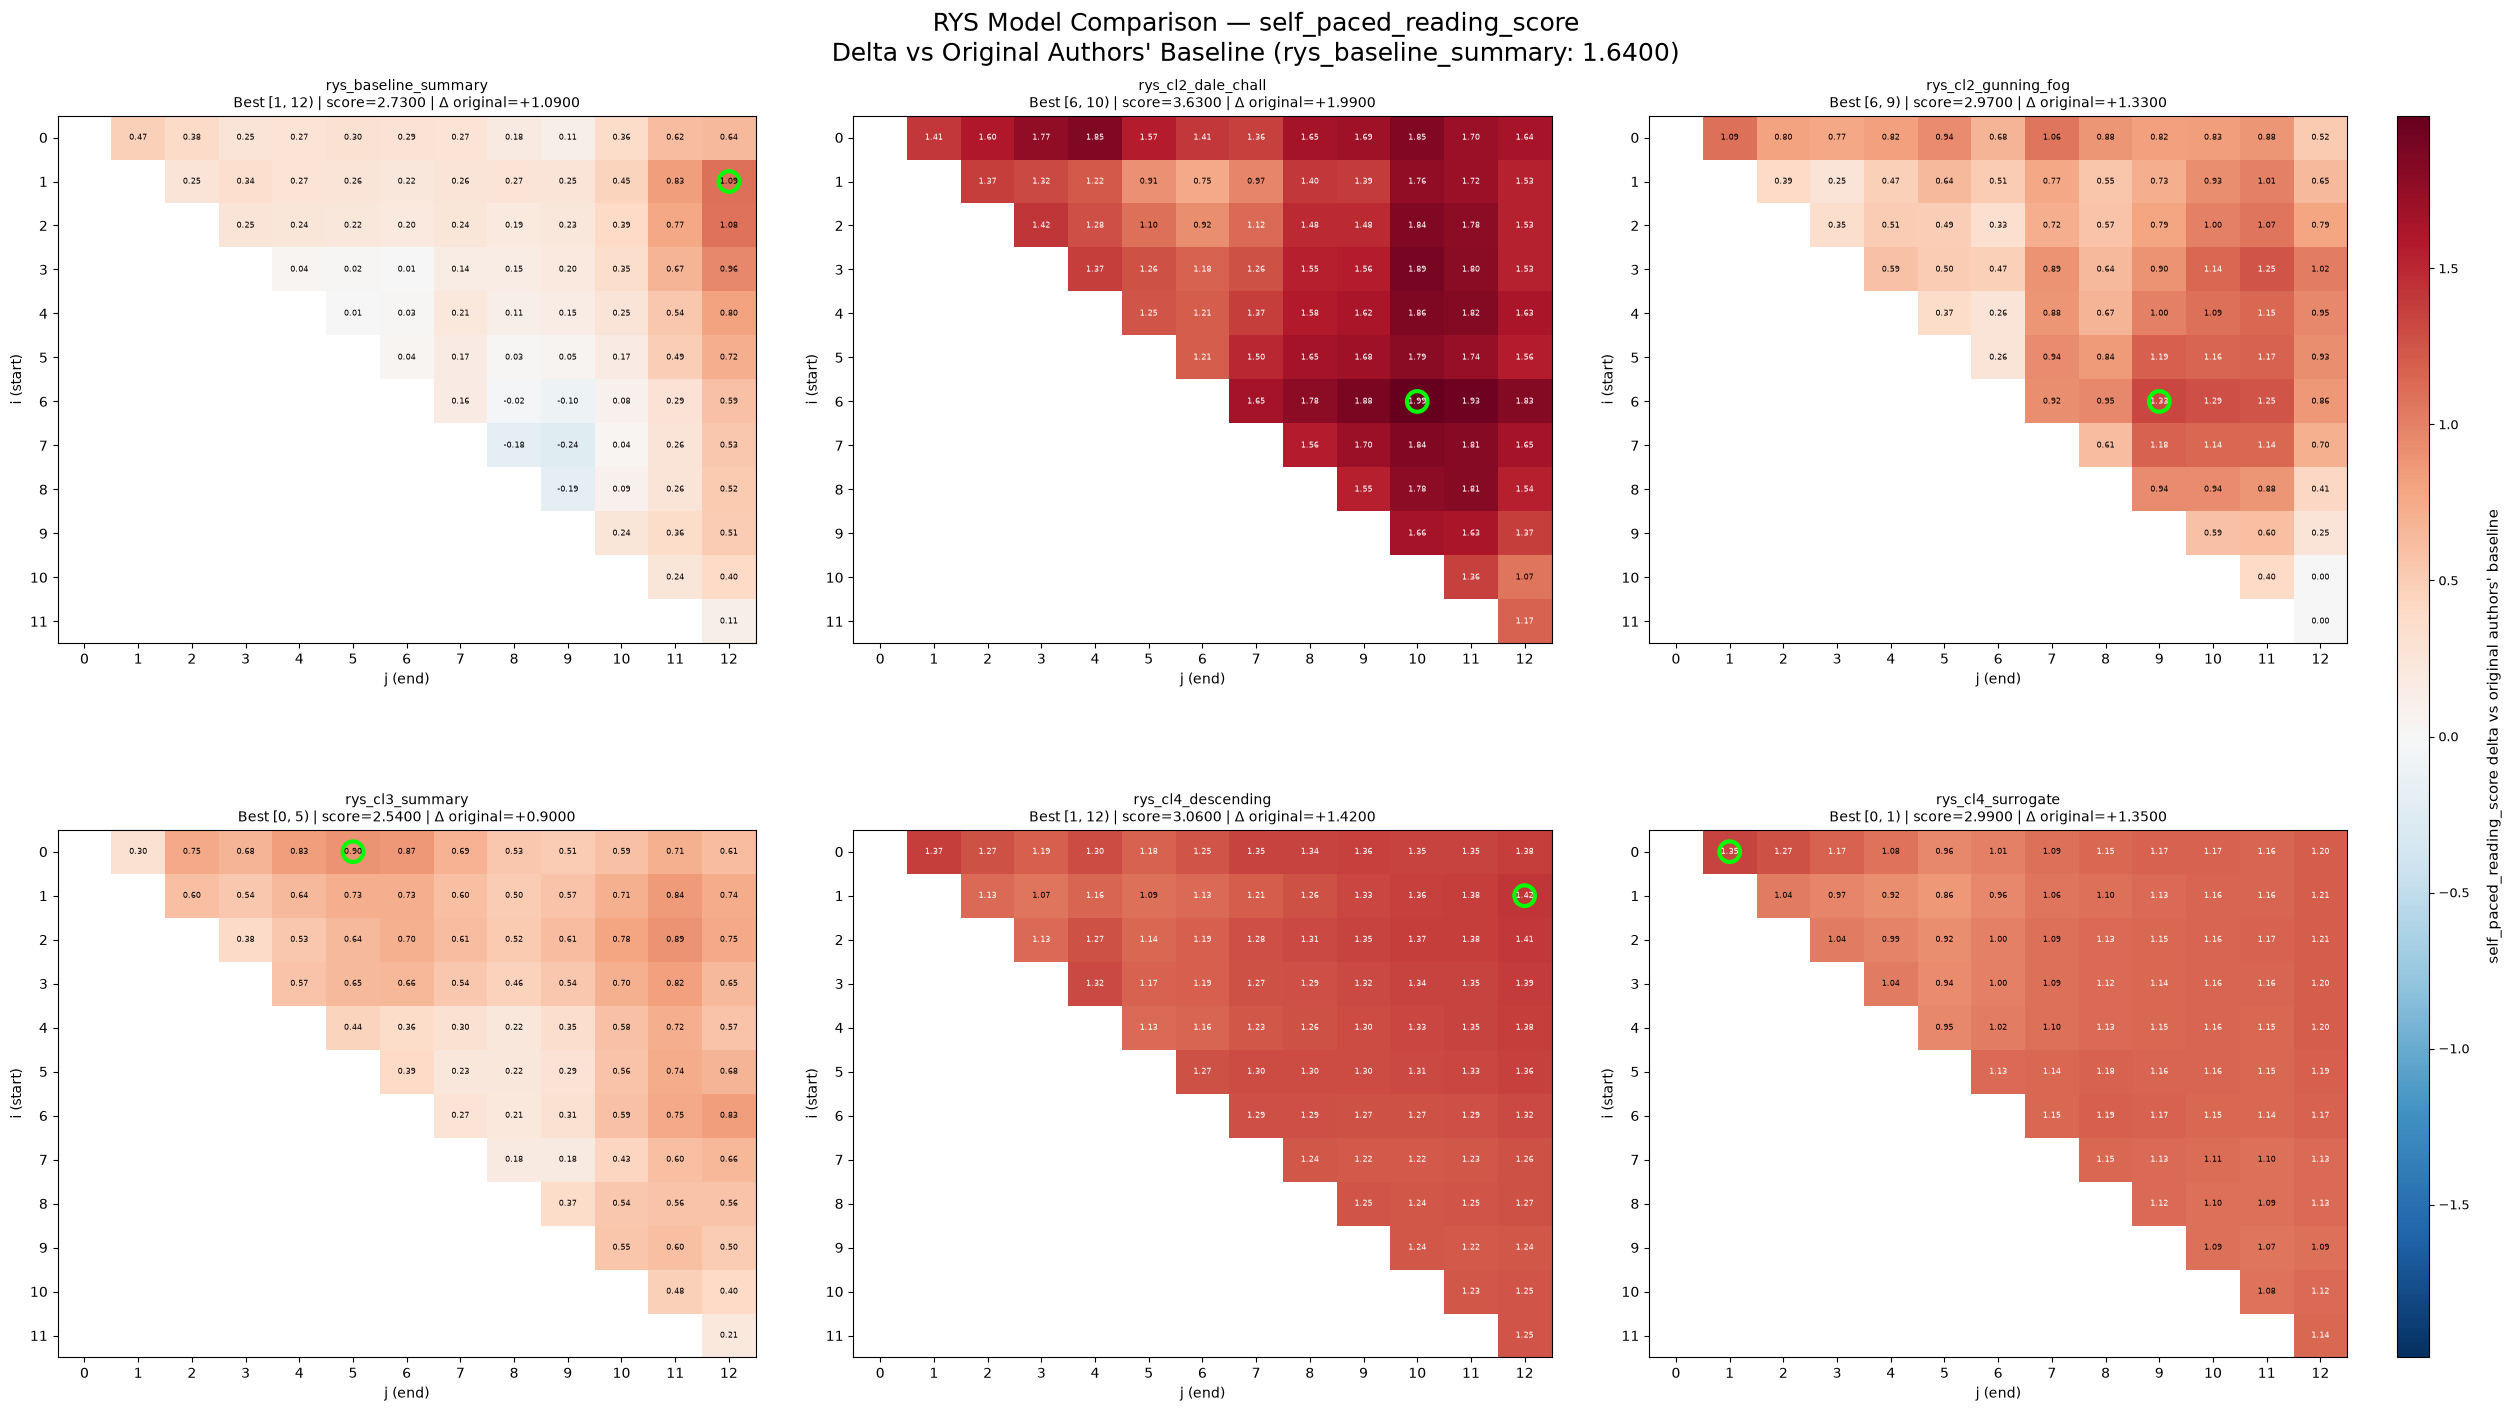

In [22]:
datasets = read_csv_files(CSV_DIRECTORY)

all_results = plot_all_metrics_comparison(
    datasets=datasets,
    metrics=METRICS,
    reference_model="rys_baseline_summary",
    use_delta=True,
    annotate=True,
)

In [29]:
baseline_df = datasets["rys_cl2_dale_chall"]

original_baseline_row = baseline_df[
    (baseline_df["rys_start"] == 6)
    & (baseline_df["rys_end"] == 7)
]

print(original_baseline_row.to_string(index=False))

 rys_start  rys_end  duplicated_layers  execution_layers  blimp_fast  supplement_fast  ewok_fast  entity_tracking_fast  combined_sentence_acc  eye_tracking_score  self_paced_reading_score               output_dir
         6        7                  1                13       65.25             61.6      50.64                 18.24                48.9325                6.74                      3.29 results_rys_fast/rys_6_7
